<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/agglomerative_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.


In [2]:
import pandas as pd
import os

# Assuming the dataset contains CSV files, we will try to load the first CSV found.
# You might need to adjust this based on the actual file names in the dataset.

dataset_files = os.listdir(path)
csv_files = [f for f in dataset_files if f.endswith('.csv')]

if csv_files:
    # Assuming the main data is in the first CSV file found
    data_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(data_file_path)
    print("DataFrame 'df' loaded successfully. Here are the first 5 rows:")
    print(df.head())
else:
    print(f"No CSV files found in the dataset directory: {path}. Please check the dataset content.")


DataFrame 'df' loaded successfully. Here are the first 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


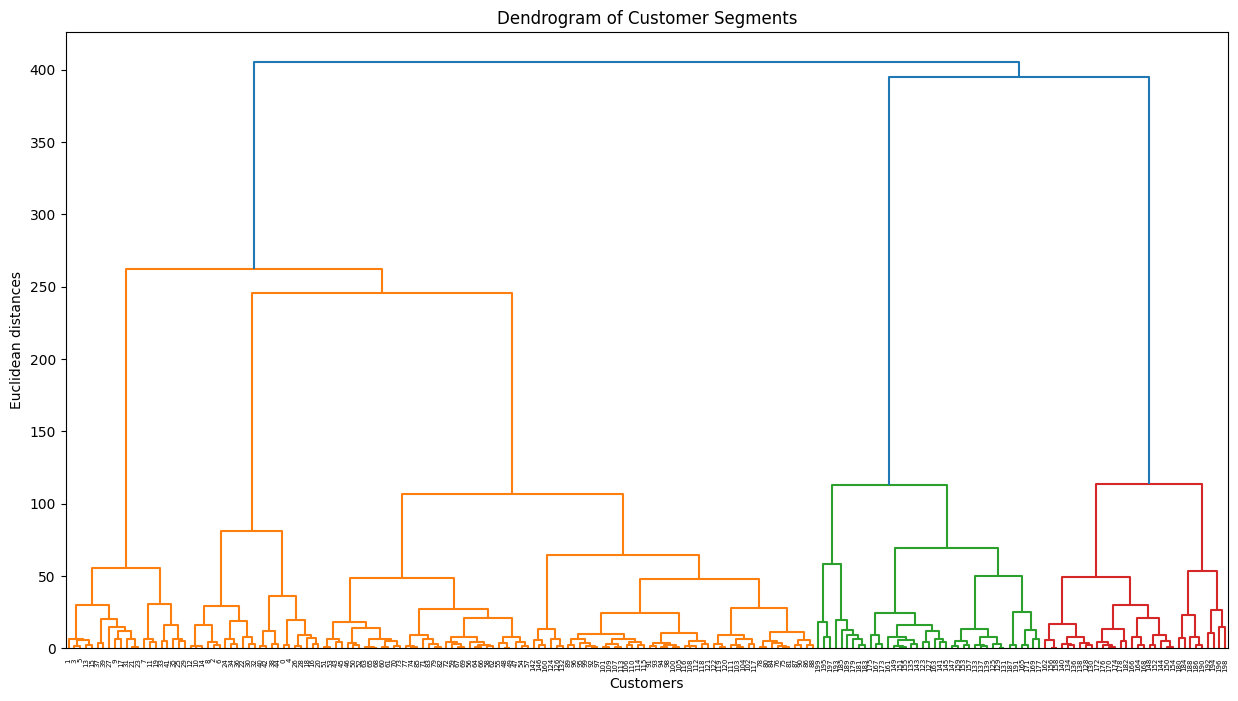

In [3]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# Select relevant features for clustering (Annual Income and Spending Score)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Compute the linkage matrix
# Using 'ward' method which minimizes the variance of the clusters being merged.
linkage_matrix = sch.linkage(X, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 8))
sch.dendrogram(linkage_matrix)
plt.title('Dendrogram of Customer Segments')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()


In [5]:
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative Clustering with 5 clusters (a common choice for this dataset)
# You can choose a different number of clusters by visually inspecting the dendrogram
n_clusters = 5
hc = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')

# Fit the model and get the cluster labels
y_hc = hc.fit_predict(X)

# Add the cluster labels to the original DataFrame
df['Cluster'] = y_hc

print(f"Agglomerative Clustering applied with {n_clusters} clusters.")
print("DataFrame with new 'Cluster' column:")
display(df.head())

Agglomerative Clustering applied with 5 clusters.
DataFrame with new 'Cluster' column:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


### Step 1: Outlier Detection

Let's identify potential outliers in the `Annual Income (k$)` and `Spending Score (1-100)` features using the Interquartile Range (IQR) method. Outliers can sometimes skew clustering results or indicate unusual customer behaviors.

Potential Outliers (based on IQR method for Annual Income and Spending Score):


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
198,199,Male,32,137,18,0
199,200,Male,30,137,83,2


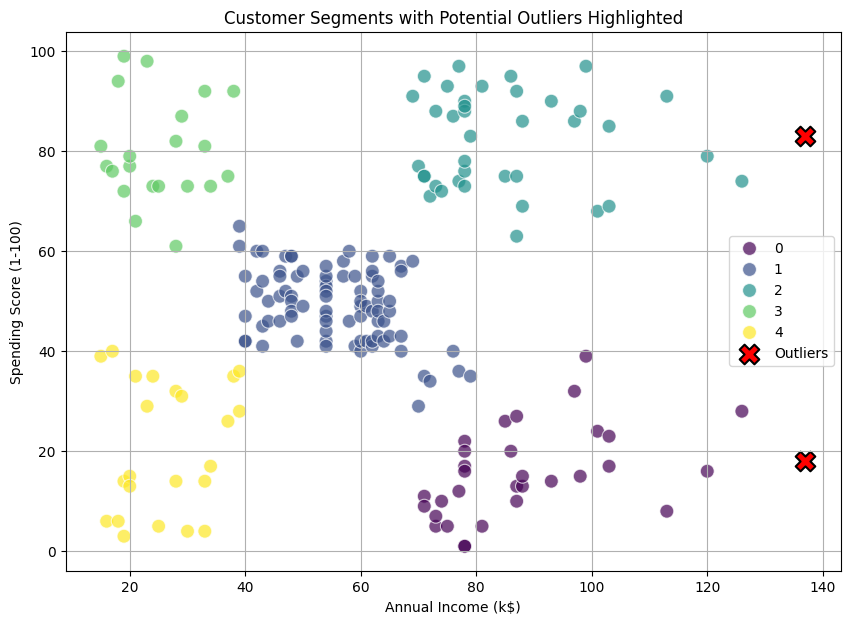

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Outlier Detection using IQR method for 'Annual Income (k$)'
Q1_income = df['Annual Income (k$)'].quantile(0.25)
Q3_income = df['Annual Income (k$)'].quantile(0.75)
IQR_income = Q3_income - Q1_income
outlier_threshold_upper_income = Q3_income + 1.5 * IQR_income
outlier_threshold_lower_income = Q1_income - 1.5 * IQR_income

# Outlier Detection using IQR method for 'Spending Score (1-100)'
Q1_spending = df['Spending Score (1-100)'].quantile(0.25)
Q3_spending = df['Spending Score (1-100)'].quantile(0.75)
IQR_spending = Q3_spending - Q1_spending
outlier_threshold_upper_spending = Q3_spending + 1.5 * IQR_spending
outlier_threshold_lower_spending = Q1_spending - 1.5 * IQR_spending

# Identify potential outliers in either dimension
outliers_df = df[
    (df['Annual Income (k$)'] < outlier_threshold_lower_income) |
    (df['Annual Income (k$)'] > outlier_threshold_upper_income) |
    (df['Spending Score (1-100)'] < outlier_threshold_lower_spending) |
    (df['Spending Score (1-100)'] > outlier_threshold_upper_spending)
]

print("Potential Outliers (based on IQR method for Annual Income and Spending Score):")
if not outliers_df.empty:
    display(outliers_df)
else:
    print("No significant outliers detected based on the IQR method for these features.")

# Visualize clusters with outliers highlighted
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.7)
if not outliers_df.empty:
    plt.scatter(outliers_df['Annual Income (k$)'], outliers_df['Spending Score (1-100)'],
                color='red', marker='X', s=200, label='Outliers', edgecolor='black', linewidth=1.5)
plt.title('Customer Segments with Potential Outliers Highlighted')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

### Step 2: Clustering Evaluation

Since clustering is an unsupervised learning task, we don't have true labels to compare against. Instead, we use internal validation metrics to assess the quality of the clusters. Here are a few common ones:

*   **Silhouette Score**: Measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). Higher values indicate better-defined clusters.
*   **Davies-Bouldin Index**: Measures the average similarity ratio of each cluster with its most similar cluster. Lower values indicate better clustering.
*   **Calinski-Harabasz Index**: Also known as the Variance Ratio Criterion, it is the ratio of the sum of between-clusters dispersion and within-cluster dispersion. Higher values correspond to models with better-defined clusters.

In [7]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Calculate Silhouette Score
silhouette = silhouette_score(X, df['Cluster'])
print(f"Silhouette Score: {silhouette:.3f}")

# Calculate Davies-Bouldin Index
davies_bouldin = davies_bouldin_score(X, df['Cluster'])
print(f"Davies-Bouldin Index: {davies_bouldin:.3f}")

# Calculate Calinski-Harabasz Index
calinski_harabasz = calinski_harabasz_score(X, df['Cluster'])
print(f"Calinski-Harabasz Index: {calinski_harabasz:.3f}")

Silhouette Score: 0.553
Davies-Bouldin Index: 0.578
Calinski-Harabasz Index: 243.071


### Step 3 (Revised): Hyperparameter Tuning - Finding Optimal Number of Clusters

One of the most important 'hyperparameters' in unsupervised clustering, particularly Agglomerative Clustering, is the number of clusters (`n_clusters`). We can use internal validation metrics (like the ones calculated previously) to help determine the optimal number. We'll iterate through a range of possible cluster numbers and plot their scores.

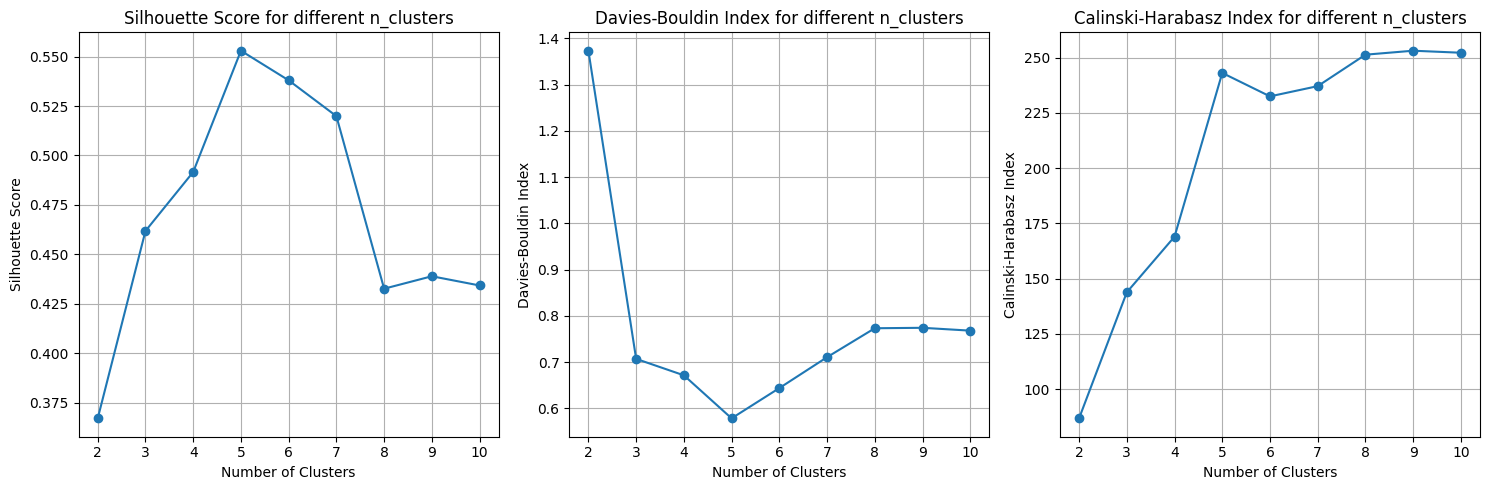

In [10]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import numpy as np

# Define a range of clusters to evaluate
range_n_clusters = range(2, 11) # From 2 to 10 clusters

silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for n_clusters in range_n_clusters:
    # Apply Agglomerative Clustering
    hc_tuned = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
    y_hc_tuned = hc_tuned.fit_predict(X)

    # Calculate metrics
    silhouette_scores.append(silhouette_score(X, y_hc_tuned))
    davies_bouldin_scores.append(davies_bouldin_score(X, y_hc_tuned))
    calinski_harabasz_scores.append(calinski_harabasz_score(X, y_hc_tuned))

# Plotting the evaluation metrics
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title('Silhouette Score for different n_clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(range_n_clusters, davies_bouldin_scores, marker='o')
plt.title('Davies-Bouldin Index for different n_clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Index')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(range_n_clusters, calinski_harabasz_scores, marker='o')
plt.title('Calinski-Harabasz Index for different n_clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Calinski-Harabasz Index')
plt.grid(True)

plt.tight_layout()
plt.show()

# You can use these plots to decide the optimal number of clusters.
# For example, look for the peak in Silhouette/Calinski-Harabasz or the trough in Davies-Bouldin.

### Step 3: Train/Test Split and Accuracy (Supervised Prediction of Cluster Labels)

Traditionally, train/test split and 'accuracy' are concepts from supervised learning where you have a known target variable. In clustering, the 'labels' (clusters) are *generated*. However, if your goal is to build a predictive model that can assign new, unseen customer data to one of these learned clusters, then you would treat the generated `Cluster` column as your target variable.

Below is an example of how you would perform a train/test split and train a simple classifier (e.g., a RandomForestClassifier) to predict these cluster labels, and then evaluate its classification accuracy.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y) for this *derived* supervised task
# X are the original features used for clustering
# y are the cluster labels generated by Agglomerative Clustering
y = df['Cluster']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

# Train a classifier (e.g., RandomForestClassifier) to predict cluster labels
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = classifier.predict(X_test)

# Evaluate the classifier's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nClassifier Accuracy: {accuracy:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training set size: 140 samples
Test set size: 60 samples

Classifier Accuracy: 0.967

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.92      0.96        25
           2       1.00      1.00      1.00        12
           3       0.86      1.00      0.92         6
           4       1.00      1.00      1.00         7

    accuracy                           0.97        60
   macro avg       0.95      0.98      0.97        60
weighted avg       0.97      0.97      0.97        60



### Step 4: Visualize Clusters

Let's visualize the results of the Agglomerative Clustering by plotting 'Annual Income (k$)' against 'Spending Score (1-100)' and coloring each point by its assigned cluster. This helps in understanding the characteristics of each segment.

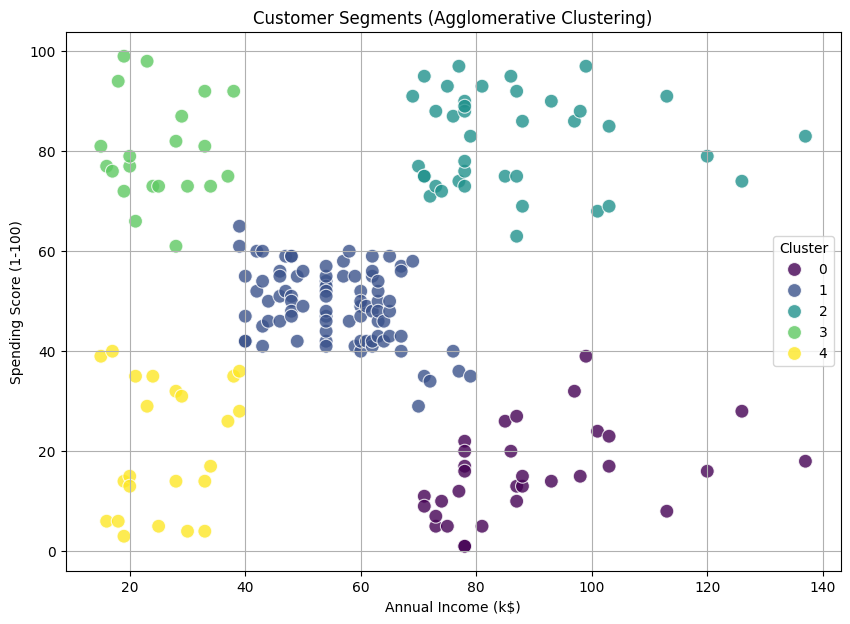

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments (Agglomerative Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()